In [30]:
from openpyxl import load_workbook
from openpyxl.cell.cell import Cell
from typing import Dict, Any, List, Optional
from openpyxl.utils.cell import coordinate_from_string, column_index_from_string, get_column_letter
import re
import pandas as pd

pd.set_option('display.min_rows', 22)
pd.set_option('display.max_columns', None)

In [31]:
force_file_path = "force_file.xlsx"
plan_file_path = "plan_file.xlsx"

In [32]:
def build_protocol_df(protocol_numbers, pct_static_values, matrix):
    if not matrix:
        return pd.DataFrame(columns=['row_idx', 'protocol_number', 'pct_static', 'v1', 'v2', 'v3'])

    n_rows = len(matrix)
    n_cols = len(matrix[0])
    n_blocks_in_matrix = n_cols // 3
    n_blocks = min(len(protocol_numbers), len(pct_static_values), n_blocks_in_matrix)

    records = []
    for b in range(n_blocks):
        p = protocol_numbers[b]
        pct = pct_static_values[b]
        c0, c1, c2 = b*3, b*3+1, b*3+2

        for r in range(n_rows):
            v1, v2, v3 = matrix[r][c0], matrix[r][c1], matrix[r][c2]
            # можно добавить фильтр пустых строк, если нужно:
            # if all(x in (None, '') for x in (v1, v2, v3)): continue
            records.append({
                'row_idx': r + 6,           # реальный номер строки Excel (если стартовали с 6)
                'protocol_number': p,
                'pct_static': pct,
                'v': v1,
                'p': v2,
                'f': v3,
            })

    return pd.DataFrame(records)

In [33]:
def read_step_blocks(ws, start_col_letter='F', start_row=6, block_width=3, gap=1):
    start_col = column_index_from_string(start_col_letter)
    step = block_width + gap

    # Список всех потенциальных колонок (F,G,H, J,K,L, N,O,P, ...)
    col_indices = []
    c = start_col
    while c <= ws.max_column:
        for i in range(block_width):
            if c + i <= ws.max_column:
                col_indices.append(c + i)
        c += step
    if not col_indices:
        return []

    min_c, max_c = col_indices[0], col_indices[-1]
    offset = min_c  # для индексации в кортеже iter_rows

    data = []
    last_nonempty_row = -1
    rightmost_used_idx = -1  # индекс в col_indices (самый правый реально использованный столбец)

    # Один проход по строкам, без Cell-объектов
    for r, row_vals in enumerate(ws.iter_rows(min_row=start_row, max_row=ws.max_row,
                                              min_col=min_c, max_col=max_c,
                                              values_only=True), start=start_row):
        # извлекаем только нужные колонки из окна [min_c..max_c]
        picked = [row_vals[c - offset] for c in col_indices]
        # проверяем непустоту и самый правый реально используемый столбец
        any_nonempty = False
        for j, v in enumerate(picked):
            if v not in (None, ''):
                any_nonempty = True
                if j > rightmost_used_idx:
                    rightmost_used_idx = j
        data.append(picked)
        if any_nonempty:
            last_nonempty_row = r

    # Обрезаем пустой «хвост» по строкам и по столбцам (справа)
    if last_nonempty_row == -1 or rightmost_used_idx == -1:
        return []

    rows_to = last_nonempty_row - start_row + 1
    cols_to = rightmost_used_idx + 1
    data = [row[:cols_to] for row in data[:rows_to]]
    return data  # матрица: строки x столбцы (F,G,H, J,K,L, ... до реально заполненных)

In [34]:
def values_by_step(ws, start_addr='G2', step_cols=4, stop_when_empty=True, max_col=None):
    col_letter, row = coordinate_from_string(start_addr)
    col = column_index_from_string(col_letter)

    # если не задали верхнюю границу — идём до первой пустой
    vals = []
    while True:
        addr = f"{get_column_letter(col)}{row}"
        v = ws[addr].value
        if stop_when_empty and (v is None or v == ""):
            break
        vals.append(v)
        col += step_cols
        if max_col and col > max_col:
            break
    return vals

def clean_protocol_number(raw: str) -> str:
    # Удаляем лидирующее "№" и лишние пробелы
    raw = raw.strip()
    raw = re.sub(r"^[№#\s]*", '', raw, flags=re.IGNORECASE)
    return raw.strip()

def extract_percent_from_text(text: str) -> Optional[float]:
    # Ожидается вид "Pст (1%)" — извлекаем число в скобках
    # Поддержка вариантов с запятой: 1,5%
    m = re.search(r"\(([-+]?\d+(?:[\.,]\d+)?)%\)", text)
    if not m:
        # fallback: искать первое число, затем знак %
        m = re.search(r"([-+]?\d+(?:[\.,]\d+)?)\s*%", text)
    if not m:
        return None
    try:
        return float(m.group(1).replace(',', '.'))
    except ValueError:
        return None

In [35]:
wb = load_workbook(filename=force_file_path, data_only=True, read_only=True)

force_protocol_dfs = pd.DataFrame()
sheets_data: List[Dict[str, Any]] = []
for ws in wb.worksheets:
    # Общие значения для листа
    energy_j = ws['C5'].value  # Энергия удара, Дж
    velocity_ms = ws['D5'].value  # Скорость удара, м/с
    force_n = ws['E5'].value  # Сила удара (P), Н

    # получение номеров протоколов
    protocol_numbers = values_by_step(ws, 'G2', step_cols=4, stop_when_empty=True)
    protocol_numbers = [clean_protocol_number(str(n)) for n in protocol_numbers]
    
    # получение процентов статического поджатия
    pct_static_values = values_by_step(ws, 'G4', step_cols=4, stop_when_empty=True)
    pct_static_values = [extract_percent_from_text(str(v)) for v in pct_static_values]

    # получение данных для каждого протокола
    matrix = read_step_blocks(ws, start_col_letter='F', start_row=6, block_width=3, gap=1)

    force_protocol_df = build_protocol_df(protocol_numbers, pct_static_values, matrix)
    force_protocol_df.drop(columns=['row_idx'], inplace=True)

    force_protocol_df['energy_j'] = energy_j
    force_protocol_df['velocity_ms'] = velocity_ms
    force_protocol_df['force_n'] = force_n

    force_protocol_dfs = pd.concat([force_protocol_dfs, force_protocol_df], ignore_index=True)

force_protocol_dfs

,protocol_number,pct_static,v,p,f,energy_j,velocity_ms,force_n
0,133,1.0,0.000000e+00,0.0,0.000367,25,3.0,108826
1,133,1.0,5.712865e-07,0.0,0.000380,25,3.0,108826
2,133,1.0,1.142573e-06,0.0,0.000391,25,3.0,108826
3,133,1.0,1.999502e-06,0.0,0.000401,25,3.0,108826
4,133,1.0,2.570788e-06,0.0,0.000408,25,3.0,108826
5,133,1.0,3.427716e-06,0.0,0.000413,25,3.0,108826
6,133,1.0,3.999002e-06,0.0,0.000415,25,3.0,108826
7,133,1.0,4.855930e-06,0.0,0.000414,25,3.0,108826
8,133,1.0,5.427217e-06,0.0,0.000408,25,3.0,108826
9,133,1.0,6.284145e-06,0.0,0.000398,25,3.0,108826


In [36]:
wb = load_workbook(filename=plan_file_path, data_only=True, read_only=True)
ws = wb.active

def parse_pct(text):
    if text is None:
        return None
    m = re.search(r'\(([\d.,]+)\s*%?\)', str(text))
    return float(m.group(1).replace(',', '.')) if m else None

# Диапазоны
data_start_row = 8
header_start_row = 7
step = 3

data_min_c = column_index_from_string('C')
data_max_c = column_index_from_string('V')

prot_min_c = column_index_from_string('N')
prot_max_c = column_index_from_string('X')

# Заголовки данных (только C:V)
header_row_for_data = 5
data_headers = [ws.cell(row=5, column=c).value or get_column_letter(c)
                for c in range(column_index_from_string('C'), column_index_from_string('M') + 1)]

# Pст проценты из N5:X5
pstat_labels_row = 5
pstat_labels = next(ws.iter_rows(min_row=pstat_labels_row, max_row=pstat_labels_row,
                                 min_col=prot_min_c, max_col=prot_max_c, values_only=True))
pstat_pct_by_col = {prot_min_c + i: parse_pct(v) for i, v in enumerate(pstat_labels)}

records = []
r_data, r_head = data_start_row, header_start_row

while r_data <= ws.max_row:
    prot_row = next(ws.iter_rows(min_row=r_head, max_row=r_head,
                                 min_col=prot_min_c, max_col=prot_max_c,
                                 values_only=True))
    data_row = next(ws.iter_rows(min_row=r_data, max_row=r_data,
                                 min_col=data_min_c, max_col=data_max_c,
                                 values_only=True))
    # значения p_static_value из той же строки r_data по колонкам N:X
    pstatic_values_row = next(ws.iter_rows(min_row=r_data, max_row=r_data,
                                           min_col=prot_min_c, max_col=prot_max_c,
                                           values_only=True))

    if all(p in (None, '') for p in prot_row) and all(v in (None, '') for v in data_row):
        break
    if all(v in (None, '') for v in data_row):
        break

    for i, p in enumerate(prot_row):
        if p in (None, ''):
            continue
        col_idx = prot_min_c + i
        rec = {
            'excel_row': r_data,
            'protocol_number': p,
            'p_static': pstat_pct_by_col.get(col_idx),
            'p_static_value': pstatic_values_row[i],  # только в этот столбец, без добавления N:X в df
        }
        # добавляем только C:V
        rec.update({col: val for col, val in zip(data_headers, data_row)})
        records.append(rec)

    r_data += step
    r_head += step

plan_protocol_df = pd.DataFrame(records)
needed = ['excel_row', 'protocol_number', 'p_static', 'p_static_value'] + data_headers
plan_protocol_df = plan_protocol_df.loc[:, [c for c in needed if c in plan_protocol_df.columns]]
plan_protocol_df.drop(columns=['excel_row'], inplace=True)
plan_protocol_df['protocol_number'] = plan_protocol_df['protocol_number'].astype(str).map(clean_protocol_number)
plan_protocol_df

,protocol_number,p_static,p_static_value,L1/L2,L1 (м),d1 (м),m1 (кг),L2 (м),d2 (м),Т (с),"А, (Дж)","V, (м/с)","С1,2 (кг/с)","Р, (Н)"
0,1,1.0,2439.865368,1,0.16,0.048,1.13,0.16,0.048,0.000062,25,6.651901,73358.4384,243986.536797
1,2,5.0,12199.326840,1,0.16,0.048,1.13,0.16,0.048,0.000062,25,6.651901,73358.4384,243986.536797
2,3,8.0,19518.922944,1,0.16,0.048,1.13,0.16,0.048,0.000062,25,6.651901,73358.4384,243986.536797
3,4,10.0,24398.653680,1,0.16,0.048,1.13,0.16,0.048,0.000062,25,6.651901,73358.4384,243986.536797
4,5,12.0,29278.384416,1,0.16,0.048,1.13,0.16,0.048,0.000062,25,6.651901,73358.4384,243986.536797
5,6,25.0,60996.634199,1,0.16,0.048,1.13,0.16,0.048,0.000062,25,6.651901,73358.4384,243986.536797
6,7,50.0,121993.268398,1,0.16,0.048,1.13,0.16,0.048,0.000062,25,6.651901,73358.4384,243986.536797
7,8,75.0,182989.902598,1,0.16,0.048,1.13,0.16,0.048,0.000062,25,6.651901,73358.4384,243986.536797
8,9,100.0,243986.536797,1,0.16,0.048,1.13,0.16,0.048,0.000062,25,6.651901,73358.4384,243986.536797
9,10,150.0,365979.805195,1,0.16,0.048,1.13,0.16,0.048,0.000062,25,6.651901,73358.4384,243986.536797


C:\Users\Admin\AppData\Local\Temp\ipykernel_12920\334242864.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['f'] = df['f'].clip(lower=0)
C:\Users\Admin\AppData\Local\Temp\ipykernel_12920\334242864.py:92: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  S = np.trapz(y[i0:i1+1], x[i0:i1+1])


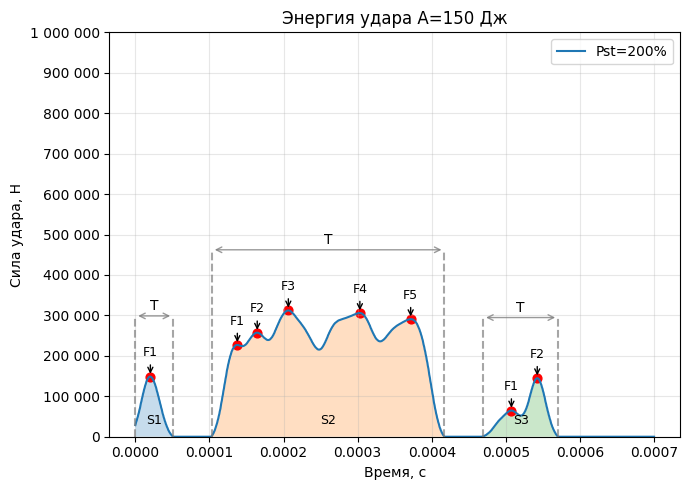

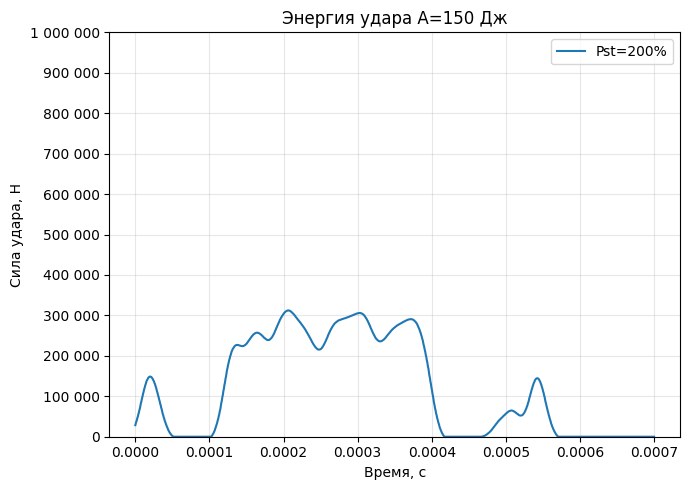

,pulse_id,extremum_id,extremum_type,v,f,duration_v,area,v_start,v_end
0,1,1,max,0.000020,148716.82270,0.000051,4.186331,0.000000,0.000051
1,2,1,max,0.000138,227007.70120,0.000314,74.013044,0.000103,0.000417
2,2,2,max,0.000164,257246.92110,0.000314,74.013044,0.000103,0.000417
3,2,3,max,0.000206,312253.02640,0.000314,74.013044,0.000103,0.000417
4,2,4,max,0.000303,305920.38480,0.000314,74.013044,0.000103,0.000417
5,2,5,max,0.000372,290727.62470,0.000314,74.013044,0.000103,0.000417
6,3,1,max,0.000507,64772.44443,0.000101,6.092157,0.000469,0.000570
7,3,2,max,0.000542,144701.29100,0.000101,6.092157,0.000469,0.000570


In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import pandas as pd

df = force_protocol_dfs[force_protocol_dfs['protocol_number'] == "198"]
p_static = int(df['pct_static'].mean())
energy_j = int(df['energy_j'].mean())

df['f'] = df['f'].clip(lower=0)

# исходные данные
d = df[['v', 'f']].dropna().sort_values('v')
x = d['v'].to_numpy()
y = d['f'].to_numpy()

# пики
try:
    from scipy.signal import find_peaks
    peaks, _   = find_peaks(y,  prominence=1e-6)
    troughs, _ = find_peaks(-y, prominence=1e-6)
except ImportError:
    dy = np.gradient(y, x)
    s = np.sign(dy)
    peaks   = np.where((s[:-1] > 0) & (s[1:] < 0))[0] + 1
    troughs = np.where((s[:-1] < 0) & (s[1:] > 0))[0] + 1

# фильтрация экстремумов
MIN_F = 1_000
peaks   = peaks[y[peaks]   >= MIN_F]
troughs = troughs[y[troughs] >= MIN_F]
peaks   = peaks[y[peaks]   >= 0]
troughs = troughs[y[troughs] >= 0]

# ==== 1) параметры выделения импульсов ====
ON_THR  = 1_000
OFF_THR = 1_000

above_on  = y >= ON_THR
above_off = y >= OFF_THR

starts = np.where((~above_on[:-1])  & (above_on[1:]))[0]  + 1
stops  = np.where((above_off[:-1]) & (~above_off[1:]))[0] + 1

# если график сразу начинается выше порога — первая область
if above_on[0]:
    starts = np.r_[0, starts]

# починка непарных случаев
if len(stops) and len(starts):
    if stops[0] < starts[0]:
        stops = stops[1:]
    if len(starts) > len(stops):
        stops = np.r_[stops, len(y)-1]
elif len(starts) and not len(stops):
    stops = np.array([len(y)-1])
elif len(stops) and not len(starts):
    starts = np.array([0])

pulse_windows = [(s, e) for s, e in zip(starts, stops) if e - s > 2]

# ==== 2) график ====
plt.figure(figsize=(7,5))
plt.plot(x, y, linewidth=1.5, label=f'Pst={p_static}%')

# ==== 3) выделение импульсов + верхняя стрелка "T" ====
areas = []
pulse_data = []
max_h_used = 0.0  # чтобы потом адекватно задать ylim

for k, (i0, i1) in enumerate(pulse_windows, 1):
    # заливка области
    plt.fill_between(x[i0:i1+1], 0, y[i0:i1+1], alpha=0.25)

    # «штыри»
    h = y[i0:i1+1].max() + 150_000
    max_h_used = max(max_h_used, h)
    plt.vlines(x[i0], 0, h, colors='gray', linestyles='--', alpha=0.7)
    plt.vlines(x[i1], 0, h, colors='gray', linestyles='--', alpha=0.7)

    # верхняя двусторонняя стрелка (коннектор) и подпись T
    xm = (x[i0] + x[i1]) / 2
    plt.annotate(
        '', xy=(x[i1], h), xytext=(x[i0], h),
        arrowprops=dict(arrowstyle='<->', lw=1, color='gray', alpha=0.8)
    )
    # небольшой вертикальный отступ над стрелкой
    t_offset = 0.02 * max(y.max(), 1.0)
    plt.text(xm, h + t_offset, 'T', ha='center', va='bottom', fontsize=10)

    # площадь и длительность
    S = np.trapz(y[i0:i1+1], x[i0:i1+1])
    duration_v = x[i1] - x[i0]
    v_start, v_end = float(x[i0]), float(x[i1])

    # максимумы внутри области — и на график, и в df
    in_pulse_max = peaks[(peaks >= i0) & (peaks <= i1)]
    for j, p in enumerate(in_pulse_max, 1):
        plt.scatter(x[p], y[p], c='r', s=40)
        plt.annotate(
            f'F{j}', xy=(x[p], y[p]),
            xytext=(x[p], y[p] + 50_000),
            arrowprops=dict(arrowstyle='->', lw=1),
            ha='center', fontsize=9
        )

    areas.append((k, S, xm))

    if len(in_pulse_max) == 0:
        pulse_data.append({
            "pulse_id": k, "extremum_id": None, "extremum_type": None,
            "v": None, "f": None,
            "duration_v": float(duration_v), "area": float(S),
            "v_start": v_start, "v_end": v_end
        })
    else:
        for j, p in enumerate(in_pulse_max, 1):
            pulse_data.append({
                "pulse_id": k, "extremum_id": j, "extremum_type": "max",
                "v": float(x[p]), "f": float(y[p]),
                "duration_v": float(duration_v), "area": float(S),
                "v_start": v_start, "v_end": v_end
            })

# подписи площадей S1, S2...
for k, S, xm in areas:
    plt.text(xm, max(ON_THR*1.1, y.max()*0.08), f'S{k}',
             ha='center', va='bottom', fontsize=9)

# оформление
fmt_int = FuncFormatter(lambda val, pos: f'{int(val):,}'.replace(',', ' '))
plt.xlabel('Время, с')
plt.ylabel('Сила удара, Н')
plt.title(f'Энергия удара A={energy_j} Дж')

# ось Y — так, чтобы влезали верхние стрелки
upper = max(1_000_000, max_h_used * 1.08, y.max() * 1.05)
plt.ylim(0, upper)

plt.yticks(np.arange(0, 1_000_001, 100_000))
plt.gca().yaxis.set_major_formatter(fmt_int)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
plt.plot(x, y, linewidth=1.5, label=f'Pst={p_static}%')

plt.xlabel('Время, с')
plt.ylabel('Сила удара, Н')
plt.title(f'Энергия удара A={energy_j} Дж')

# тот же формат оси Y (можно оставить авто, если хочешь)
plt.ylim(0, 1_000_000)
plt.yticks(np.arange(0, 1_000_001, 100_000))
plt.gca().yaxis.set_major_formatter(fmt_int)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# таблица с максимумами
pulse_df = pd.DataFrame(pulse_data)
pulse_df